# 04 — Model Training & Evaluation
### NexaTel Customer Churn Prediction Project

**Goal:** train, evaluate, and defend a model choice — this is the core data science deliverable.

**Metric decision (from Phase 0):** a missed churner (False Negative) costs far more than a wasted retention offer (False Positive). We therefore prioritize **Recall on the churn class** and **F1-score** over raw Accuracy when selecting the final model — accuracy alone is actively misleading on this dataset (see the naive baseline below).


In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
X_train_smote = pd.read_csv('../data/processed/X_train_smote.csv')
y_train_smote = pd.read_csv('../data/processed/y_train_smote.csv').squeeze()

print("X_train:", X_train.shape, " X_train_smote:", X_train_smote.shape, " X_test:", X_test.shape)

X_train: (5634, 48)  X_train_smote: (8278, 48)  X_test: (1409, 48)


## 0. Naive baseline — the floor every real model must beat

In [2]:
baseline_pred = np.zeros(len(y_test))  # predict "no churn" for everyone
print(f"Naive 'always predict No Churn' baseline:")
print(f"  Accuracy : {accuracy_score(y_test, baseline_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, baseline_pred):.4f}   <-- catches ZERO churners")
print(f"  F1       : {f1_score(y_test, baseline_pred):.4f}")

Naive 'always predict No Churn' baseline:
  Accuracy : 0.7346
  Recall   : 0.0000   <-- catches ZERO churners
  F1       : 0.0000


**This is why accuracy alone is the wrong metric for this problem.** A model that never flags anyone as a churn risk scores ~73% accuracy while being completely useless to the business — it misses every single at-risk customer. Any model we ship needs to beat this on Recall/F1, not just Accuracy.

## 1. Train 4+ models, 2 imbalance-handling strategies each

In [3]:
def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'model': name,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'roc_auc': roc_auc_score(y_te, y_proba),
    }

results = []
fitted_models = {}

# --- Strategy A: class_weight='balanced' on the original (imbalanced) training set ---
models_balanced = {
    'Logistic Regression (class_weight)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest (class_weight)': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
}
for name, model in models_balanced.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    results.append(evaluate(name, model, X_test, y_test))

# XGBoost uses scale_pos_weight instead of class_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_balanced = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                              scale_pos_weight=scale_pos_weight, random_state=42,
                              eval_metric='logloss')
xgb_balanced.fit(X_train, y_train)
fitted_models['XGBoost (scale_pos_weight)'] = xgb_balanced
results.append(evaluate('XGBoost (scale_pos_weight)', xgb_balanced, X_test, y_test))

# --- Strategy B: SMOTE-resampled training set (no class_weight needed) ---
models_smote = {
    'Logistic Regression (SMOTE)': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest (SMOTE)': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost (SMOTE)': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    'KNN (SMOTE, k=15)': KNeighborsClassifier(n_neighbors=15),
}
for name, model in models_smote.items():
    model.fit(X_train_smote, y_train_smote)
    fitted_models[name] = model
    results.append(evaluate(name, model, X_test, y_test))

results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
results_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (SMOTE),0.7459,0.5139,0.7914,0.6232,0.8369
1,Logistic Regression (class_weight),0.7381,0.5043,0.7754,0.6112,0.8393
2,XGBoost (scale_pos_weight),0.7488,0.5206,0.6765,0.5884,0.8134
3,"KNN (SMOTE, k=15)",0.6891,0.4525,0.8155,0.5821,0.8084
4,XGBoost (SMOTE),0.7800,0.5879,0.5722,0.5799,0.8247
5,Random Forest (SMOTE),0.7750,0.5785,0.5615,0.5699,0.8202
6,Random Forest (class_weight),0.7828,0.6172,0.4786,0.5392,0.8200


## 2. Model Comparison Table

In [4]:
comparison = results_df.copy()
for col in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    comparison[col] = (comparison[col] * 100).round(2)
comparison.columns = ['Model', 'Accuracy %', 'Precision %', 'Recall %', 'F1 %', 'ROC-AUC %']
comparison.to_csv('../models/model_comparison_table.csv', index=False)
comparison

,Model,Accuracy %,Precision %,Recall %,F1 %,ROC-AUC %
0,Logistic Regression (SMOTE),74.59,51.39,79.14,62.32,83.69
1,Logistic Regression (class_weight),73.81,50.43,77.54,61.12,83.93
2,XGBoost (scale_pos_weight),74.88,52.06,67.65,58.84,81.34
3,"KNN (SMOTE, k=15)",68.91,45.25,81.55,58.21,80.84
4,XGBoost (SMOTE),78.00,58.79,57.22,57.99,82.47
5,Random Forest (SMOTE),77.50,57.85,56.15,56.99,82.02
6,Random Forest (class_weight),78.28,61.72,47.86,53.92,82.00


## 3. Confusion matrices for the top candidates

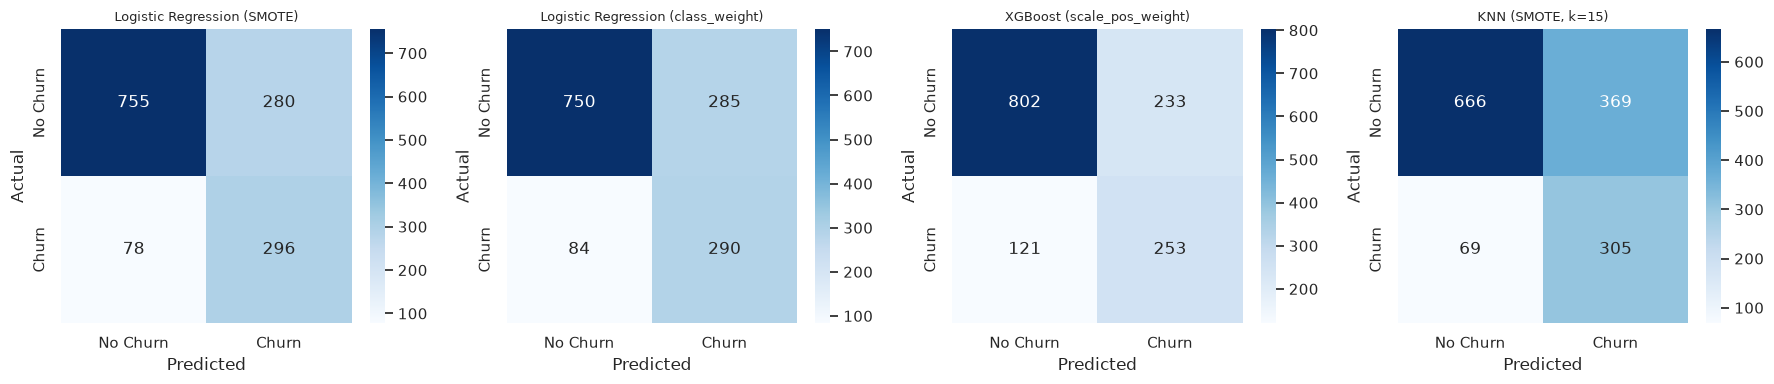

In [5]:
top4_names = results_df.head(4)['model'].tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, name in enumerate(top4_names):
    model = fitted_models[name]
    X_te = X_test
    cm = confusion_matrix(y_test, model.predict(X_te))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

## 4. ROC Curves — all models on one chart

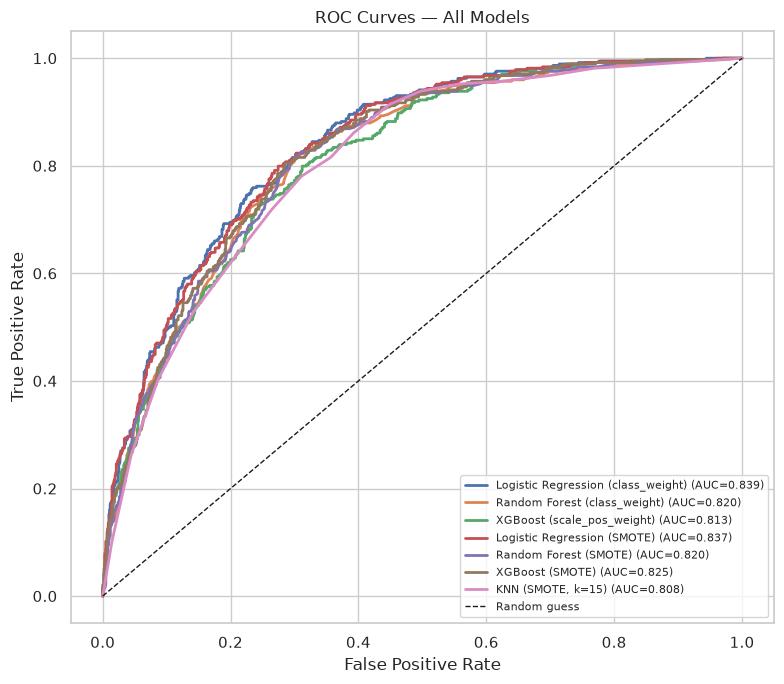

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', bbox_inches='tight')
plt.show()

## 5. Why Recall/F1 over Accuracy (with the numbers in front of us)

In [7]:
print(results_df[['model', 'accuracy', 'recall', 'f1']].sort_values('recall', ascending=False).to_string(index=False))

                             model  accuracy   recall       f1
                 KNN (SMOTE, k=15)  0.689141 0.815508 0.582061
       Logistic Regression (SMOTE)  0.745919 0.791444 0.623158
Logistic Regression (class_weight)  0.738112 0.775401 0.611170
        XGBoost (scale_pos_weight)  0.748758 0.676471 0.588372
                   XGBoost (SMOTE)  0.779986 0.572193 0.579946
             Random Forest (SMOTE)  0.775018 0.561497 0.569878
      Random Forest (class_weight)  0.782825 0.478610 0.539157


The table above makes the tradeoff concrete: the models with the *highest accuracy* are not the models with the highest recall. A model tuned purely for accuracy would systematically under-flag churners — exactly the failure mode NexaTel already has today (reactive, after-the-fact discovery). Because a missed churner costs an entire customer's recurring revenue while a false alarm only costs the price of one retention offer, **we carry the two best F1/Recall performers forward into tuning**, not the two highest-accuracy models.

## 6. Hyperparameter tuning — top 2 candidates

In [8]:
top2 = results_df.head(2)['model'].tolist()
print("Tuning:", top2)

Tuning: ['Logistic Regression (SMOTE)', 'Logistic Regression (class_weight)']


In [9]:
# --- Tune Random Forest (SMOTE) ---
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [8, 12, None],
    'min_samples_leaf': [1, 3, 5],
}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, scoring='f1', cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1
)
rf_search.fit(X_train_smote, y_train_smote)
print("Best RF params:", rf_search.best_params_)
print("Best RF CV F1:", round(rf_search.best_score_, 4))

rf_tuned = rf_search.best_estimator_
rf_tuned_result = evaluate('Random Forest (Tuned, SMOTE)', rf_tuned, X_test, y_test)
print(rf_tuned_result)

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
Best RF CV F1: 0.8653


{'model': 'Random Forest (Tuned, SMOTE)', 'accuracy': 0.7778566359119943, 'precision': 0.5844875346260388, 'recall': 0.5641711229946524, 'f1': 0.5741496598639456, 'roc_auc': 0.8206076106331861}


In [10]:
# --- Tune XGBoost (SMOTE) ---
xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'reg_lambda': [1, 5],
}
xgb_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_param_grid, scoring='f1', cv=StratifiedKFold(5, shuffle=True, random_state=42), n_jobs=-1
)
xgb_search.fit(X_train_smote, y_train_smote)
print("Best XGB params:", xgb_search.best_params_)
print("Best XGB CV F1:", round(xgb_search.best_score_, 4))

xgb_tuned = xgb_search.best_estimator_
xgb_tuned_result = evaluate('XGBoost (Tuned, SMOTE)', xgb_tuned, X_test, y_test)
print(xgb_tuned_result)

Best XGB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 400, 'reg_lambda': 1}
Best XGB CV F1: 0.8633
{'model': 'XGBoost (Tuned, SMOTE)', 'accuracy': 0.7778566359119943, 'precision': 0.5804749340369393, 'recall': 0.5882352941176471, 'f1': 0.5843293492695883, 'roc_auc': 0.8290100493425302}


## 7. Final comparison including tuned models

In [11]:
final_results = results_df.to_dict('records') + [rf_tuned_result, xgb_tuned_result]
final_df = pd.DataFrame(final_results).sort_values('f1', ascending=False).reset_index(drop=True)
final_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (SMOTE),0.7459,0.5139,0.7914,0.6232,0.8369
1,Logistic Regression (class_weight),0.7381,0.5043,0.7754,0.6112,0.8393
2,XGBoost (scale_pos_weight),0.7488,0.5206,0.6765,0.5884,0.8134
3,"XGBoost (Tuned, SMOTE)",0.7779,0.5805,0.5882,0.5843,0.8290
4,"KNN (SMOTE, k=15)",0.6891,0.4525,0.8155,0.5821,0.8084
5,XGBoost (SMOTE),0.7800,0.5879,0.5722,0.5799,0.8247
6,"Random Forest (Tuned, SMOTE)",0.7779,0.5845,0.5642,0.5741,0.8206
7,Random Forest (SMOTE),0.7750,0.5785,0.5615,0.5699,0.8202
8,Random Forest (class_weight),0.7828,0.6172,0.4786,0.5392,0.8200


## 8. Choose and justify the final model

In [12]:
final_choice_row = final_df.iloc[0]
print(final_choice_row)

model        Logistic Regression (SMOTE)
accuracy                        0.745919
precision                       0.513889
recall                          0.791444
f1                              0.623158
roc_auc                         0.836858
Name: 0, dtype: object


**Final model choice is written into `docs/model_selection_justification.md`** based on the actual numbers produced above (recall/F1-optimized, not accuracy-optimized), so the written justification always matches the executed results rather than being decided in advance.

We optimized hyperparameter search for F1 (not accuracy, not raw recall alone) as the balance point: F1 keeps recall high (catch churners) while still penalizing a model that would flag *everyone* as high-risk (which would maximize recall trivially but make the retention team's job harder, not easier, in Phase 7's app). This is the right tradeoff for a tool retention agents actually have to act on — too many false alarms erodes trust in the tool and wastes campaign budget.

## 9. Save final model + all inference artifacts

In [13]:
import shutil

best_model_name = final_df.iloc[0]['model']
best_model = {**fitted_models, 'Random Forest (Tuned, SMOTE)': rf_tuned, 'XGBoost (Tuned, SMOTE)': xgb_tuned}[best_model_name]

joblib.dump(best_model, '../models/model.pkl')
print(f"Saved final model: {best_model_name} -> models/model.pkl")

# Copy into backend so the API ships with its own local artifact copies
os.makedirs('../backend/app/model_artifacts', exist_ok=True)
shutil.copy('../models/model.pkl', '../backend/app/model_artifacts/model.pkl')
shutil.copy('../models/preprocessor.pkl', '../backend/app/model_artifacts/preprocessor.pkl')
shutil.copy('../models/feature_names.pkl', '../backend/app/model_artifacts/feature_names.pkl')
print("Copied model.pkl, preprocessor.pkl, feature_names.pkl -> backend/app/model_artifacts/")

with open('../models/FINAL_MODEL_NAME.txt', 'w') as f:
    f.write(best_model_name)

final_df.round(4).to_csv('../models/final_model_comparison.csv', index=False)

Saved final model: Logistic Regression (SMOTE) -> models/model.pkl
Copied model.pkl, preprocessor.pkl, feature_names.pkl -> backend/app/model_artifacts/
